In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
import os
%matplotlib inline

base_path = '/work/hawkins_lab/vulcan/data/vulcan'

# Electricity

In [2]:
elec_par_file = os.path.join(base_path,'parquet','vulcan_SC2_epa_climate.parquet')

df = gpd.read_parquet(elec_par_file)

# Create columns that assign decile numbers for each treatment variable
df['treat_density'] = df['d1a']
df['treat_diversity'] = df['d2b_e5mixa']

In [3]:
var_list = ['p_highschool','p_owner','pct_ao0','avg_hh_size',
 'med_dwelling_age','all_cdd', 'all_hdd', 'stc2erta', 'w_p_lowwag',
  'treat_density', 'treat_diversity']

In [4]:
# Compute correlation matrix
corr_matrix = df.loc[:,var_list].corr(method="pearson")

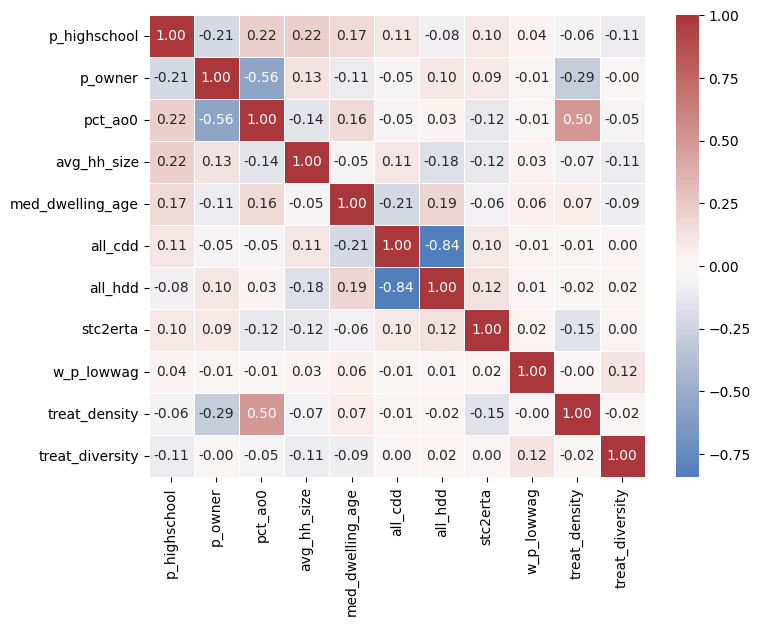

In [5]:
# Set up the figure size
plt.figure(figsize=(8, 6))

# Create heatmap
sns.heatmap(corr_matrix, annot=True, cmap="vlag", fmt=".2f", linewidths=0.5, center=0)

# # Title
# plt.title("Pearson Correlation Heatmap", fontsize=14)
plt.savefig("/work/hawkins_lab/vulcan/results/elec_heatmap.pdf", format='pdf')

In [6]:
imp_df = pd.read_csv('/work/hawkins_lab/vulcan/results/importance_electricity.csv')

In [7]:
df_agg = imp_df.groupby(['Segment', 'Treatment', 'Feature'], group_keys=False).agg(
    min_importance=('Importance', 'min'),
    median_importance=('Importance', 'median'),
    sum_importance=('Importance', 'sum')
).reset_index()  # Ensure Segment, Treatment, and Feature are columns

# Step 1: Compute the total sum_importance per (Segment, Treatment) group
group_order = df_agg.groupby(['Segment', 'Treatment'], as_index=False)['sum_importance'].sum()

# Step 2: Sort the groups by sum_importance in descending order
group_order = group_order.sort_values(by='sum_importance', ascending=False)[['Segment', 'Treatment']]

# Step 3: Merge sorted group order back into df_agg to preserve order
df_sorted = group_order.merge(df_agg, on=['Segment', 'Treatment']).sort_values(by=['Segment', 'Treatment', 'sum_importance'], ascending=[False, False, False])

print(df_sorted.set_index(['Segment', 'Treatment', 'Feature']))

                                    min_importance  median_importance  \
Segment Treatment Feature                                               
tot     div       w_p_lowwag              0.154011           0.413891   
                  stc2erta                0.294822           0.344642   
                  med_dwelling_age        0.039798           0.071937   
                  all_cdd                 0.003152           0.020704   
                  p_highschool           -0.005987           0.001168   
                  avg_hh_size            -0.012432           0.002541   
                  pct_ao0                -0.007466           0.001206   
        dens      stc2erta                0.122218           0.300677   
                  w_p_lowwag              0.037611           0.115563   
                  avg_hh_size            -0.004672           0.060753   
                  med_dwelling_age        0.018674           0.061158   
                  all_cdd                 0.018466 

We can prioritize inclusion in the PS based on comparison of the sum of importance scores (relative contributions to R2).

**For residential CO2 and density:**
1. med_dwelling_age
2. stc2erta
3. all_cdd
4. p_highschool
5. avg_hh_size

Remaining are quite low (<0.05, or 0.01 per quintile):

5. pct_ao0 (strong correlation with density but not CO2 - interesting)
6. w_p_lowwag

**For residential CO2 and diversity:**

1. med_dwelling_age
2. stc2erta
3. all_cdd

Remaining are quite low (<0.05, or 0.01 per quintile):

4. pct_ao0
5. w_p_lowwag
6. avg_hh_size
7. p_highschool

**For total CO2 and density:**
1. stc2erta
2. w_p_lowwag
3. med_dwelling_age
4. all_cdd
5. pct_ao0
6. avg_hh_size


Remaining are quite low (<0.05, or 0.01 per quintile):

7. p_highschool

**For total CO2 and diversity:**
1. w_p_lowwag
2. stc2erta
3. med_dwelling_age
4. all_cdd

Remaining are quite low:

5. avg_hh_size
6. pct_ao0
7. p_highschool

# Transportation

In [2]:
tran_par_file = os.path.join(base_path,'parquet','vulcan_ONR_epa_climate.parquet')
df = gpd.read_parquet(tran_par_file)

# Create columns that assign quintile numbers for each treatment variable
df['treat_density'] = df['d1a']
df['treat_diversity'] = df['d2b_e5mixa']
df['treat_design'] = df['d3a']
df['d4a'] = df['d4a'].fillna(0)
df['treat_distance'] = df['d4a']
df['treat_destination'] = df['d5ar']

In [3]:
df.loc[:,['treat_design','treat_destination']].describe()

,treat_design,treat_destination
count,216290.000000,2.162900e+05
mean,15.779906,1.049770e+05
std,10.706782,1.540355e+05
min,0.000000,0.000000e+00
25%,5.628356,1.010600e+04
50%,15.655748,4.458350e+04
75%,23.376650,1.275582e+05
max,166.894521,1.220602e+06


In [4]:
var_list = ['p_highschool','p_owner','pct_ao0','avg_hh_size',
 'med_dwelling_age','totpop_cbsa', 'stc2erta', 'w_p_lowwag', 'gasprice', 'vmt_per_wo', 'annual_ghg',
  'treat_density', 'treat_diversity', 'treat_design', 'treat_distance', 'treat_destination']

df.loc[:,var_list].fillna(method="ffill").isna().sum()

/tmp/ipykernel_1999500/3535286984.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.loc[:,var_list].fillna(method="ffill").isna().sum()


p_highschool         0
p_owner              0
pct_ao0              0
avg_hh_size          0
med_dwelling_age     0
totpop_cbsa          0
stc2erta             0
w_p_lowwag           0
gasprice             0
vmt_per_wo           0
annual_ghg           0
treat_density        0
treat_diversity      0
treat_design         0
treat_distance       0
treat_destination    0
dtype: int64

In [5]:
# Compute correlation matrix
corr_matrix = df.loc[:,var_list].corr(method="pearson")

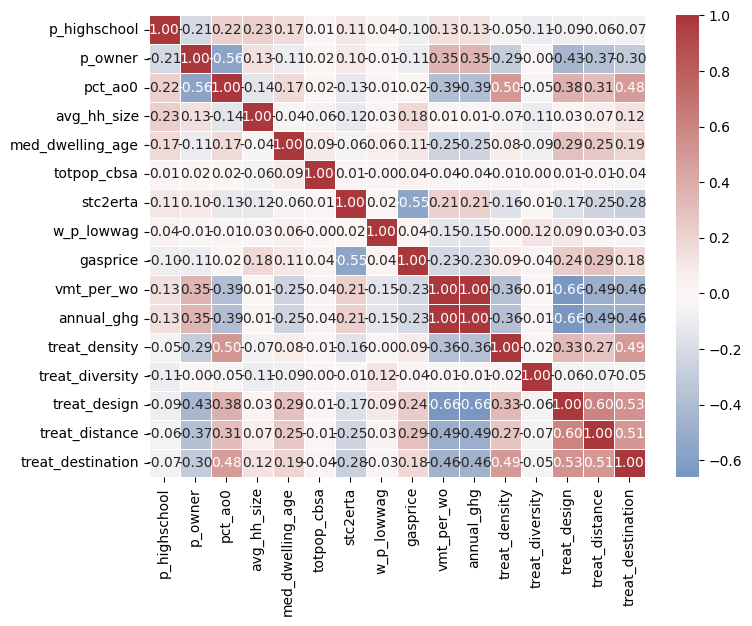

In [6]:
# Set up the figure size
plt.figure(figsize=(8, 6))

# Create heatmap
sns.heatmap(corr_matrix, annot=True, cmap="vlag", fmt=".2f", linewidths=0.5, center=0)

# Title
# plt.title("Pearson Correlation Heatmap", fontsize=14)
plt.savefig("/work/hawkins_lab/vulcan/results/transport_heatmap.pdf", format='pdf')

In [7]:
imp_df = pd.read_csv('/work/hawkins_lab/vulcan/results/importance_transport.csv')

In [8]:
df_agg = imp_df.groupby(['Segment', 'Treatment', 'Feature'], group_keys=False).agg(
    min_importance=('Importance', 'min'),
    median_importance=('Importance', 'median'),
    sum_importance=('Importance', 'sum')
).reset_index()  # Ensure Segment, Treatment, and Feature are columns

# Step 1: Compute the total sum_importance per (Segment, Treatment) group
group_order = df_agg.groupby(['Segment', 'Treatment'], as_index=False)['sum_importance'].sum()

# Step 2: Sort the groups by sum_importance in descending order
group_order = group_order.sort_values(by='sum_importance', ascending=False)[['Segment', 'Treatment']]

# Step 3: Merge sorted group order back into df_agg to preserve order
df_sorted = group_order.merge(df_agg, on=['Segment', 'Treatment']).sort_values(by=['Segment', 'Treatment', 'sum_importance'], ascending=[False, False, False])

print(df_sorted.set_index(['Segment', 'Treatment', 'Feature']))

                                    min_importance  median_importance  \
Segment Treatment Feature                                               
transpo div       med_dwelling_age        0.223890           0.427420   
                  w_p_lowwag              0.082767           0.234398   
                  pct_ao0                 0.067993           0.106277   
                  p_highschool           -0.000756           0.034008   
                  gasprice               -0.007625           0.004324   
                  stc2erta               -0.004876           0.001174   
                  totpop_cbsa            -0.004652          -0.000286   
                  avg_hh_size            -0.010564          -0.001123   
        dist      med_dwelling_age        0.415243           0.501946   
                  w_p_lowwag              0.137629           0.190158   
                  pct_ao0                 0.067169           0.093084   
                  p_highschool           -0.002677 

We can prioritize inclusion in the PS based on comparison of the minimum and median importance scores (relative contributions to R2).

**For transport CO2 and density:**
1. med_dwelling_age
2. w_p_lowwag
3. pct_ao0
4. p_highschool
5. gasprice
6. stc2erta
7. avg_hh_size

Remaining are quite low (<0.05, or 0.01 per quintile):

8. totpop_cbsa

**For transport CO2 and design:**
1. med_dwelling_age
2. w_p_lowwag
3. gasprice
5. pct_ao0
4. stc2erta
6. p_highschool
7. avg_hh_size

Remaining are quite low (<0.05, or 0.01 per quintile):

8. totpop_cbsa

**For transport CO2 and destination:**
1. med_dwelling_age
2. w_p_lowwag
3. pct_ao0
4. stc2erta
5. avg_hh_size
6. gasprice
7. p_highschool 
   
Remaining are quite low (<0.05, or 0.01 per quintile):

8. totpop_cbsa

**For transport CO2 and distance to transit:**
1. med_dwelling_age
2. w_p_lowwag
3. pct_ao0

Remaining are quite low (<0.05, or 0.01 per quintile):

4. p_highschoo
5. gasprice
6. stc2erta
7. avg_hh_size
8. totpop_cbsa

**For transport CO2 and diversity:**
1. med_dwelling_age
2. w_p_lowwag
3. pct_ao0
4. p_highschool
5. gasprice

Remaining are quite low (<0.05, or 0.01 per quintile):

6. stc2erta
7. totpop_cbsa
8. avg_hh_size 

# Residential Energy

In [15]:
res_par_file = os.path.join(base_path,'parquet','vulcan_RES_epa_climate.parquet')
df = gpd.read_parquet(res_par_file)

# Create columns that assign quintile numbers for each treatment variable
df['treat_density'] = df['d1a']
df['treat_diversity'] = df['d2b_e5mixa']

In [16]:
var_list = ['p_highschool','p_owner','pct_ao0','avg_hh_size',
 'med_dwelling_age','all_cdd', 'all_hdd', 'stc2erta', 'w_p_lowwag',
  'treat_density', 'treat_diversity']

In [17]:
# Compute correlation matrix
corr_matrix = df.loc[:,var_list].corr(method="pearson")

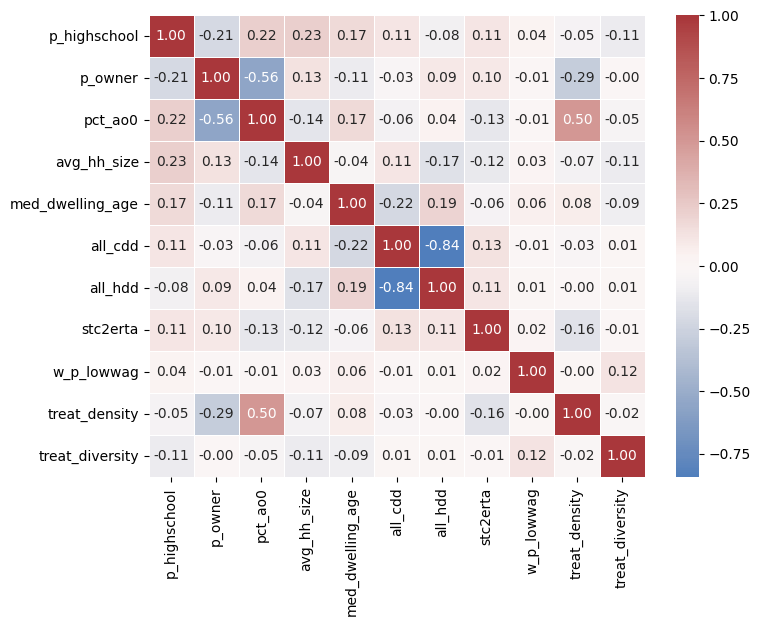

In [18]:
# Set up the figure size
plt.figure(figsize=(8, 6))

# Create heatmap
sns.heatmap(corr_matrix, annot=True, cmap="vlag", fmt=".2f", linewidths=0.5, center=0)

# # Title
# plt.title("Pearson Correlation Heatmap", fontsize=14)
plt.savefig("/work/hawkins_lab/vulcan/results/residential_heatmap.pdf", format='pdf')

In [19]:
imp_df = pd.read_csv('/work/hawkins_lab/vulcan/results/importance_residential.csv')

In [20]:
df_agg = imp_df.groupby(['Segment', 'Treatment', 'Feature'], group_keys=False).agg(
    min_importance=('Importance', 'min'),
    median_importance=('Importance', 'median'),
    sum_importance=('Importance', 'sum')
).reset_index()  # Ensure Segment, Treatment, and Feature are columns

# Step 1: Compute the total sum_importance per (Segment, Treatment) group
group_order = df_agg.groupby(['Segment', 'Treatment'], as_index=False)['sum_importance'].sum()

# Step 2: Sort the groups by sum_importance in descending order
group_order = group_order.sort_values(by='sum_importance', ascending=False)[['Segment', 'Treatment']]

# Step 3: Merge sorted group order back into df_agg to preserve order
df_sorted = group_order.merge(df_agg, on=['Segment', 'Treatment']).sort_values(by=['Segment', 'Treatment', 'sum_importance'], ascending=[False, False, False])

print(df_sorted.set_index(['Segment', 'Treatment', 'Feature']))

                                       min_importance  median_importance  \
Segment    Treatment Feature                                               
res_energy div       all_cdd                 0.746487           0.786912   
                     p_highschool            0.029691           0.042228   
                     med_dwelling_age       -0.003249           0.019318   
                     stc2erta                0.007441           0.013770   
                     w_p_lowwag             -0.000490           0.005803   
                     avg_hh_size            -0.005458           0.001420   
                     pct_ao0                -0.006881          -0.002103   
           dens      all_cdd                 0.770038           0.826252   
                     p_highschool            0.007152           0.030996   
                     stc2erta               -0.002900           0.017426   
                     med_dwelling_age       -0.007217           0.007337   
            

We can prioritize inclusion in the PS based on comparison of the minimum and median importance scores (relative contributions to R2).

**For residential CO2 and density:**
1. all_cdd
2. p_highschool
3. stc2erta
4. med_dwelling_age

Remaining are quite low (<0.05, or 0.01 per quintile):

5. pct_ao0
6. w_p_lowwag
7. avg_hh_size

**For residential CO2 and diversity:**
1. all_cdd
2. p_highschool
3. stc2erta
4. med_dwelling_age
5. w_p_lowwag
   
Remaining are quite low (<0.05, or 0.01 per quintile):

6. avg_hh_size
7. pct_ao0
